<a href="https://colab.research.google.com/github/lucaspaludo/learning-pytorch-fundamentals/blob/main/5_visualizando_etapas_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.pyplot as plt
import torch
import numpy as np

import matplotlib.pyplot as plt
import torch
import numpy as np

def visualizar_feature_maps(x, titulo="Feature Maps", tamanho=2):
    x = x.detach().cpu()

    num_filtros = x.shape[1]

    # grid automático
    grid_size = int(np.ceil(np.sqrt(num_filtros)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(tamanho, tamanho))

    if grid_size == 1:
        axes = np.array([[axes]])

    axes = axes.flatten()

    for i in range(len(axes)):
        if i < num_filtros:
            img = x[0, i]

            # normalização
            img = (img - img.min()) / (img.max() - img.min() + 1e-5)

            axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

    plt.suptitle(titulo, fontsize=10)
    plt.tight_layout(pad=0.5)
    plt.show()

In [143]:
# convertendo MNIST para um tensor de 4 dimensões (nº imagens, largura, altura, cor do canal)

transform = transforms.ToTensor()

In [144]:
# Train data
train_data = datasets.MNIST(root='/cnn_data', train=True, download=True, transform=transform)



In [145]:
# Test data
test_data = datasets.MNIST(root='/cnn_data', train=False, download=True, transform=transform)


In [146]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [147]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [148]:
# criando um batch de 10

train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [149]:
# definindo modelo CNN

conv1 = nn.Conv2d(1, 6, 3, 1)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [150]:
for i, (X_Train, y_train) in enumerate(train_data):
  break

In [151]:
X_Train.shape

torch.Size([1, 28, 28])

In [152]:
x = X_Train.view(1, 1, 28, 28) # 1 batch, 1 imagem, 28 largura, 28 altura


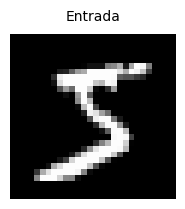

In [153]:
visualizar_feature_maps(x, "Entrada", tamanho=2)

In [154]:
# realizando primeira convolução
x = F.relu(conv1(x))



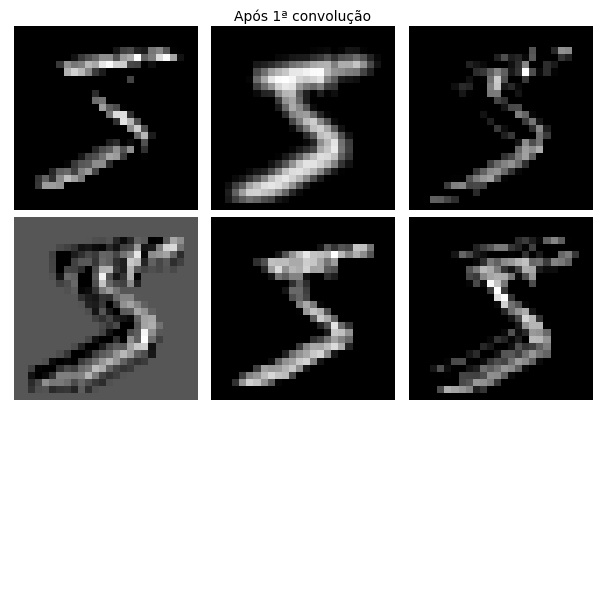

In [155]:
visualizar_feature_maps(x, "Após 1ª convolução", tamanho=6)

In [156]:
# 1 imagem, 6 filtros (kernels ou feature maps), 26 largura, 26 altura

x.shape

torch.Size([1, 6, 26, 26])

In [157]:
# passando para a camada de pooling

x = F.max_pool2d(x, 2, 2) # kernel 2 e stride 2

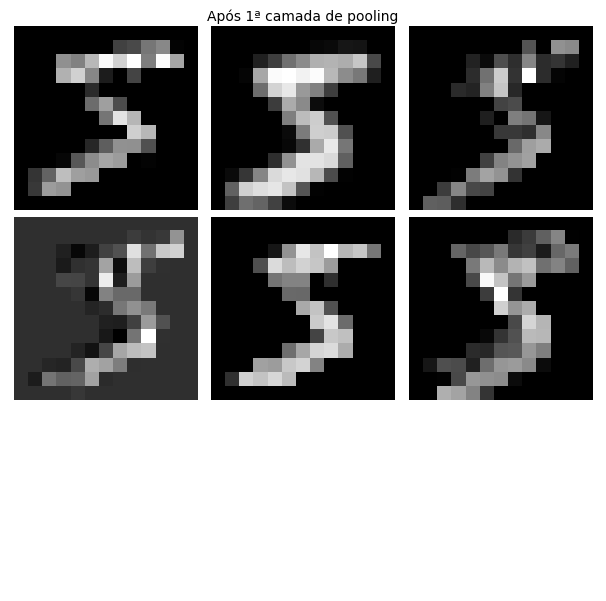

In [158]:
visualizar_feature_maps(x, "Após 1ª camada de pooling", tamanho=6)

In [159]:
x.shape # 26 // 2 = 13

torch.Size([1, 6, 13, 13])

In [160]:
# fazendo a segunda convolução
x = F.relu(conv2(x))

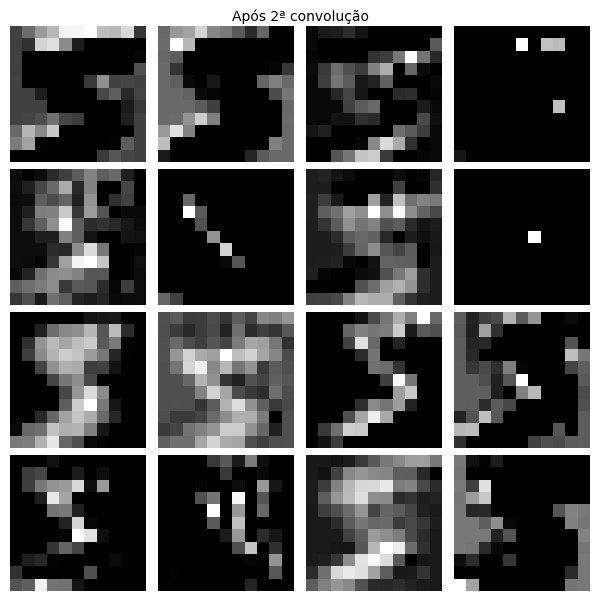

In [161]:
visualizar_feature_maps(x, "Após 2ª convolução", tamanho=6)

In [162]:
x.shape # não setamos o padding, por isso perdemos 2 pixels ao redor da imagem

torch.Size([1, 16, 11, 11])

In [163]:
x = F.max_pool2d(x, 2, 2)

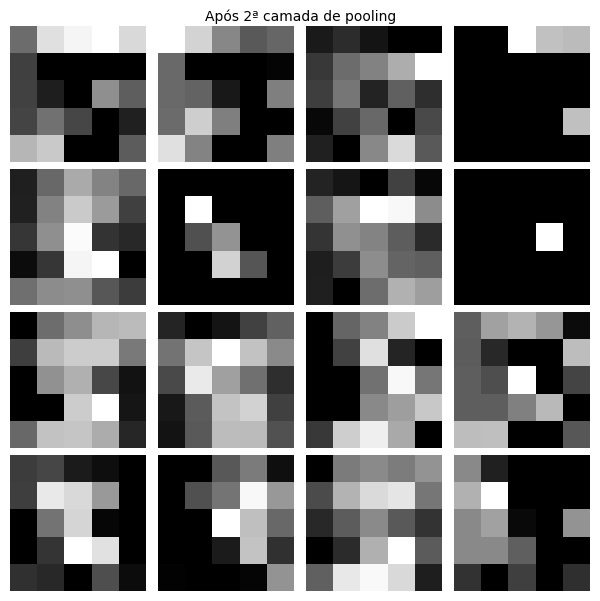

In [164]:
visualizar_feature_maps(x, "Após 2ª camada de pooling", tamanho=6)

In [165]:
x.shape # sempre arredonda para baixo pois não podemos "inventar" dados

torch.Size([1, 16, 5, 5])

In [166]:
((28 - 2) / 2 - 2) / 2

5.5